<a href="https://colab.research.google.com/github/gordon921212/Baseball-Project/blob/main/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pybaseball

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.6 MB/s eta 0:00:00


In [2]:
from pybaseball import statcast

df_pitch_by_pitch = statcast(start_dt="2025-03-01", end_dt="2025-11-30")


This is a large query, it may take a moment to complete


/usr/local/lib/python3.12/dist-packages/pybaseball/statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)


Skipping offseason dates
Skipping offseason dates


  0%|          | 0/246 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = 

In [3]:
df_in_play= df_pitch_by_pitch[df_pitch_by_pitch['description'] == 'hit_into_play']
df_in_play[['launch_speed','launch_angle','events','hit_distance_sc']]

,launch_speed,launch_angle,events,hit_distance_sc
43,71.9,-24,grounded_into_double_play,5
75,11.9,2,sac_bunt,7
82,89.8,21,double,291
209,93.8,0,field_out,47
297,104.6,39,home_run,366
...,...,...,...,...
3312,<NA>,<NA>,field_out,<NA>
3847,<NA>,<NA>,field_out,<NA>
4832,<NA>,<NA>,field_out,<NA>
2025,<NA>,<NA>,field_out,<NA>


In [ ]:
print(df_in_play['events'].unique())
print("各 events 種類的出現次數：")
print(df_in_play['events'].value_counts())

['grounded_into_double_play' 'sac_bunt' 'double' 'field_out' 'home_run'
 'force_out' 'single' 'sac_fly' 'double_play' 'field_error' 'triple'
 'fielders_choice_out' 'fielders_choice' 'sac_fly_double_play'
 'catcher_interf' 'triple_play']
各 events 種類的出現次數：
events
field_out                    79949
single                       28272
double                        8408
home_run                      6070
force_out                     3652
grounded_into_double_play     3405
sac_fly                       1397
field_error                   1112
triple                         690
sac_bunt                       596
double_play                    412
fielders_choice                412
fielders_choice_out            349
sac_fly_double_play             19
catcher_interf                  13
triple_play                      3
Name: count, dtype: int64


#二分類

In [ ]:
import pandas as pd

print("開始進行精確的標籤編碼...")

# 1. 剔除雜訊：把「捕手妨礙打擊」的無效數據直接刪掉
df_model = df_in_play[df_in_play['events'] != 'catcher_interf'].copy()

# 2. 定義安打的種類
hit_events = ['single', 'double', 'triple', 'home_run']

# 3. 標籤編碼 (Label Encoding)
# 只要是 hit_events 就是 1，其餘 11 種出局或失誤全部歸為 0
df_model['is_hit'] = df_model['events'].apply(lambda x: 1 if x in hit_events else 0)

# 4. 留下我們需要的欄位 (特徵 X 與目標 Y)
df_model = df_model[['launch_speed', 'launch_angle', 'is_hit']]

# 5. 清除雷達當機沒測到初速/仰角的缺失值
df_model = df_model.dropna()

print("========================================")
print(f"✅ 資料清理完成！共保留 {len(df_model)} 筆有效特徵資料。")
print("========================================")

# 檢查一下 0 和 1 的分佈
print(df_model['is_hit'].value_counts(normalize=True) * 100)

開始進行精確的標籤編碼...
✅ 資料清理完成！共保留 131637 筆有效特徵資料。
is_hit
0    67.77046
1    32.22954
Name: proportion, dtype: float64


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

# =========================
# 1. Prepare X and y
# =========================

# 定義 X 為 launch_speed 和 launch_angle
# 定義 Y 為 是否打中 (is_hit 在 Data Cleaning 中產生)
X = df_model[['launch_speed', 'launch_angle']]
y = df_model['is_hit']

# 第一次切分：分為 train+validation 和 test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 測試集 佔 20%
    random_state=42,  # 亂數種子
    stratify=y
)

# 第二次切分：分為 train 和 validation
# Validation 用來提早停止訓練
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("🌲 開始執行 Random Forest 的網格搜索 (Grid Search)...")

# 1. 建立基礎模型 (把固定的參數寫在這裡)
base_rf = RandomForestClassifier(
    class_weight='balanced',  # 讓模型自動處理安打與出局的數量不平衡
    random_state=42,
    n_jobs=-1                 # RF 非常適合平行運算，這裡火力全開
    # 注意：在 Grid Search 中通常會先把 oob_score 關掉，避免印出一堆警告或拖慢速度
)

# 2. 設定參數網格 (尋寶圖)
param_grid_rf = {
    'n_estimators': [100, 300, 500],       # 測試多少棵樹能讓投票結果最穩定
    'max_depth': [6, 8, 10, 12],           # 限制樹的深度，避免死背極端值
    'min_samples_split': [2, 10, 20],      # 一個節點至少要有幾顆球，才允許繼續往下切
    'min_samples_leaf': [1, 5, 10]         # 每片葉子 (最終分類) 至少要包含幾顆球
}

# 3. 設定 5-Fold 交叉驗證
cv_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. 啟動 GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid_rf,
    scoring='roc_auc',         # 目標依然是最大化 ROC-AUC
    cv=cv_rf,
    n_jobs=-1,                 # 讓多個 CPU 核心同時跑不同的參數組合
    verbose=3,
    refit=True
)

# 5. 開始訓練 (只使用 X_train, 保持 X_val/X_test 乾淨)
grid_search_rf.fit(X_train, y_train)

print("\n========================================")
print("🏆 Random Forest Grid Search 最終結果")
print("========================================")
print(f"最佳 CV ROC-AUC: {grid_search_rf.best_score_:.4f}")
print("最佳參數組合:")
print(grid_search_rf.best_params_)

# 把最強的模型存下來，準備進行後續的 F1-Score 閾值最佳化！
best_rf_model = grid_search_rf.best_estimator_

🌲 開始執行 Random Forest 的網格搜索 (Grid Search)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

🏆 Random Forest Grid Search 最終結果
最佳 CV ROC-AUC: 0.8680
最佳參數組合:
{'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 500}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ==========================================
# 步驟 1：使用最佳參數訓練最終模型
# ==========================================
print("🌲 正在使用黃金參數訓練最終 Random Forest 模型...")
best_rf_model = RandomForestClassifier(
    max_depth=10,
    min_samples_leaf=10,
    min_samples_split=2,
    n_estimators=500,
    class_weight='balanced',  # 記得保留這個處理類別不平衡的神器
    random_state=42,
    n_jobs=-1
)

# 訓練模型 (只跑這一次，速度會非常快！)
best_rf_model.fit(X_train, y_train)

🌲 正在使用黃金參數訓練最終 Random Forest 模型...


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=10, n_estimators=500, n_jobs=-1,
                       random_state=42)

🔍 正在使用獨立驗證集 (Validation Set) 預測機率...
✅ 機率計算完成！開始尋找最佳門檻...



/tmp/ipykernel_5191/875599797.py:69: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5191/875599797.py:69: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5191/875599797.py:69: UserWarning: Glyph 28858 (\N{CJK UNIFIED IDEOGRAPH-70BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5191/875599797.py:69: UserWarning: Glyph 23433 (\N{CJK UNIFIED IDEOGRAPH-5B89}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5191/875599797.py:69: UserWarning: Glyph 25171 (\N{CJK UNIFIED IDEOGRAPH-6253}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5191/875599797.py:69: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5191/875599797.py:69: UserWarning: Glyph 27231 (\N{CJK UNIFIED IDEOGRAPH-6A5F}) missi

🎯 最佳切點 (Best Threshold): 0.58
🏆 最高 F1 分數: 0.7021
----------------------------------------


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38334 (\N{CJK UNIFIED IDEOGRAPH-95BE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  fig.canvas

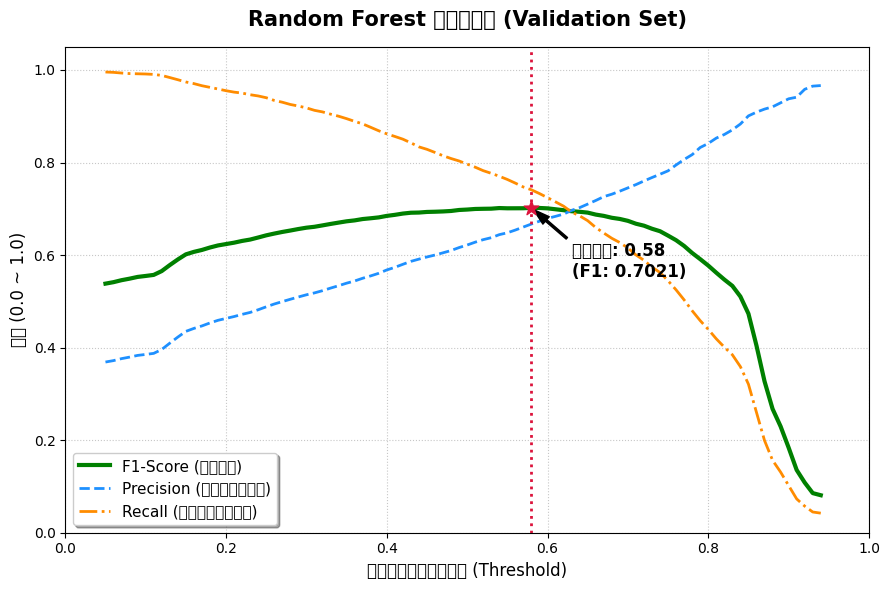

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

print("🔍 正在使用獨立驗證集 (Validation Set) 預測機率...")

# 🌟 改用驗證集 (X_val) 產生機率
# 這裡不需要 cross_val_predict 了，直接用模型預測 X_val 即可
y_val_proba_rf = best_rf_model.predict_proba(X_val)[:, 1]

print("✅ 機率計算完成！開始尋找最佳門檻...\n")

# 2. 測試各種可能的門檻
thresholds = np.arange(0.05, 0.95, 0.01)
best_threshold = 0.5
best_f1 = 0

f1_scores = []
precisions = []
recalls = []

for threshold in thresholds:
    y_val_pred_threshold = (y_val_proba_rf >= threshold).astype(int)

    # 🚨 關鍵修正：這裡必須對齊 y_val (驗證集的真實標籤)
    current_f1 = f1_score(y_val, y_val_pred_threshold)
    current_precision = precision_score(y_val, y_val_pred_threshold, zero_division=0)
    current_recall = recall_score(y_val, y_val_pred_threshold, zero_division=0)

    f1_scores.append(current_f1)
    precisions.append(current_precision)
    recalls.append(current_recall)

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print(f"🎯 最佳切點 (Best Threshold): {best_threshold:.2f}")
print(f"🏆 最高 F1 分數: {best_f1:.4f}")
print("-" * 40)

# ==========================================
# 3. 繪製閾值最佳化曲線圖
# ==========================================
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(9, 6))

plt.plot(thresholds, f1_scores, label='F1-Score (綜合表現)', color='green', lw=3)
plt.plot(thresholds, precisions, label='Precision (猜安打的命中率)', color='dodgerblue', linestyle='--', lw=2)
plt.plot(thresholds, recalls, label='Recall (真實安打的捕捉率)', color='darkorange', linestyle='-.', lw=2)

plt.axvline(x=best_threshold, color='crimson', linestyle=':', lw=2)
plt.scatter(best_threshold, best_f1, color='crimson', s=120, zorder=5, marker='*')
plt.annotate(f'最佳切點: {best_threshold:.2f}\n(F1: {best_f1:.4f})',
             xy=(best_threshold, best_f1),
             xytext=(best_threshold + 0.05, best_f1 - 0.15),
             fontsize=12, fontweight='bold',
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7))

# 標題順便改為 Validation Set，避免與之前的 CV OOF 搞混
plt.title('Random Forest 閾值最佳化 (Validation Set)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('預測為安打的機率門檻 (Threshold)', fontsize=12)
plt.ylabel('分數 (0.0 ~ 1.0)', fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc='lower left', fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

📊 正在套用最佳門檻進行最終測試集評估...



/tmp/ipykernel_5191/809679588.py:51: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5191/809679588.py:51: UserWarning: Glyph 23616 (\N{CJK UNIFIED IDEOGRAPH-5C40}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5191/809679588.py:51: UserWarning: Glyph 23433 (\N{CJK UNIFIED IDEOGRAPH-5B89}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5191/809679588.py:51: UserWarning: Glyph 25171 (\N{CJK UNIFIED IDEOGRAPH-6253}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5191/809679588.py:51: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5191/809679588.py:51: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5191/809679588.py:51: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missi

🏆 Random Forest 最終成績單 (套用最佳門檻)
使用的最佳門檻 (Threshold): 0.58
測試集準確率 (Accuracy):    0.7905
測試集 ROC-AUC:             0.8647

[詳細分類報告 Classification Report]
                  precision    recall  f1-score   support

出局 / Non-hit (0)       0.86      0.82      0.84     17843
    安打 / Hit (1)       0.66      0.73      0.69      8485

        accuracy                           0.79     26328
       macro avg       0.76      0.77      0.77     26328
    weighted avg       0.80      0.79      0.79     26328



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23616 (\N{CJK UNIFIED IDEOGRAPH-5C40}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23433 (\N{CJK UNIFIED IDEOGRAPH-5B89}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25171 (\N{CJK UNIFIED IDEOGRAPH-6253}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas

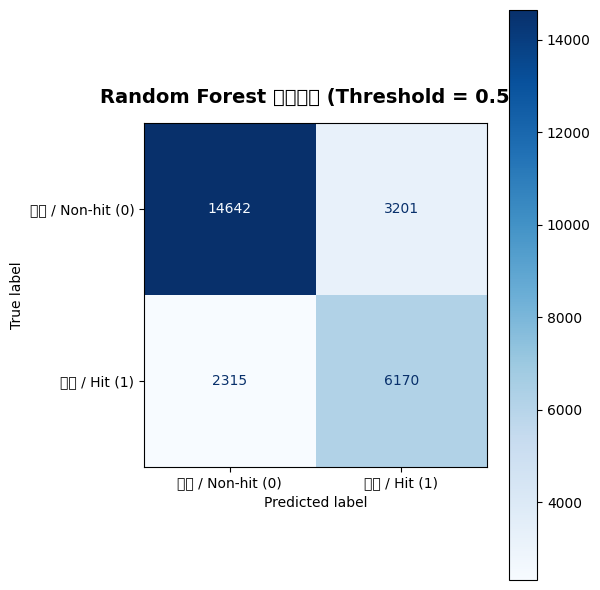

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("📊 正在套用最佳門檻進行最終測試集評估...\n")

# 1. 取得 Random Forest 在測試集上的預測機率
y_test_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

# 2. 套用剛剛找到的最佳門檻 (best_threshold) 進行二元分類判斷
# 只要機率大於等於門檻，就判定為安打 (1)，否則為出局 (0)
y_test_pred_rf_tuned = (y_test_proba_rf >= best_threshold).astype(int)

# 3. 計算最終指標
tuned_accuracy = accuracy_score(y_test, y_test_pred_rf_tuned)
# 注意：AUC 永遠是吃「機率 (proba)」，不是吃「門檻判斷後的 0/1 結果」
final_auc = roc_auc_score(y_test, y_test_proba_rf)

# ==========================================
# 4. 印出超專業的期末成績單
# ==========================================
print("========================================")
print("🏆 Random Forest 最終成績單 (套用最佳門檻)")
print("========================================")
print(f"使用的最佳門檻 (Threshold): {best_threshold:.2f}")
print(f"測試集準確率 (Accuracy):    {tuned_accuracy:.4f}")
print(f"測試集 ROC-AUC:             {final_auc:.4f}")
print("\n[詳細分類報告 Classification Report]")
print(classification_report(
    y_test,
    y_test_pred_rf_tuned,
    target_names=['出局 / Non-hit (0)', '安打 / Hit (1)']
))

# ==========================================
# 5. 繪製高質感的混淆矩陣
# ==========================================
cm = confusion_matrix(y_test, y_test_pred_rf_tuned)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['出局 / Non-hit (0)', '安打 / Hit (1)']
)

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # Windows 顯示中文
plt.rcParams['axes.unicode_minus'] = False
fig, ax = plt.subplots(figsize=(6, 6))

# 使用藍色漸層 (Blues)，數值顯示為整數 (d)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f"Random Forest 混淆矩陣 (Threshold = {best_threshold:.2f})", fontsize=14, fontweight='bold', pad=15)
plt.grid(False) # 關掉背景網格線，讓矩陣更清晰
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("開始進行最終期末考：使用測試集 (Test Set) 評估模型...")

# 1. 讓訓練好的隨機森林模型對測試集進行預測
y_test_pred = rf_model.predict(X_test)          # 預測絕對結果 (0 或 1)
y_test_proba = rf_model.predict_proba(X_test)[:, 1] # 預測安打機率 (xBA)

# 2. 計算最終關鍵指標
final_accuracy = accuracy_score(y_test, y_test_pred)
final_auc = roc_auc_score(y_test, y_test_proba)

print("\n========================================")
print("🎓 期末專案最終測試集 (Test Set) 評估報告")
print("========================================")
print(f"最終準確率 (Final Accuracy): {final_accuracy:.4f}")
print(f"最終 ROC-AUC 分數:           {final_auc:.4f}")

# 3. 印出詳細的分類報告 (包含 Precision, Recall, F1-score)
print("\n[詳細分類報告]")
print(classification_report(y_test, y_test_pred, target_names=['出局 (0)', '安打 (1)']))


開始進行最終期末考：使用測試集 (Test Set) 評估模型...

🎓 期末專案最終測試集 (Test Set) 評估報告
最終準確率 (Final Accuracy): 0.7673
最終 ROC-AUC 分數:           0.8593

[詳細分類報告]
              precision    recall  f1-score   support

      出局 (0)       0.89      0.75      0.81     17843
      安打 (1)       0.61      0.80      0.69      8485

    accuracy                           0.77     26328
   macro avg       0.75      0.78      0.75     26328
weighted avg       0.80      0.77      0.77     26328



In [ ]:
import pandas as pd

# 1. 確保你使用的是二元分類模型 (0=出局, 1=安打)
# 取得預測機率 (xBA)
xBA_array = rf_model.predict_proba(X_test)[:, 1]

# 2. 建立一個新的 DataFrame 來進行數據分析
# 把 X_test 複製過來，避免改到原始資料
df_analysis = X_test.copy()

# 加入真實結果與我們算出來的 xBA
df_analysis['Actual_Result'] = y_test
df_analysis['xBA'] = xBA_array

# 3. 算出「運氣值 (Luck Factor)」
# 公式：真實結果 (1或0) - 預期安打率 (xBA)
# 如果結果是 1 (安打)，但 xBA 只有 0.10 -> 運氣值 = +0.90 (超幸運鳥安)
# 如果結果是 0 (出局)，但 xBA 高達 0.95 -> 運氣值 = -0.95 (超衰平飛被接殺)
df_analysis['Luck_Factor'] = df_analysis['Actual_Result'] - df_analysis['xBA']

print("xBA 分析表建置完成！")
print(df_analysis.head())

xBA 分析表建置完成！
      launch_speed  launch_angle  Actual_Result       xBA  Luck_Factor
644           51.5           -69              0  0.379144    -0.379144
4310          73.1           -47              0  0.245289    -0.245289
1419          89.2           -41              0  0.188492    -0.188492
469           91.0            37              0  0.063485    -0.063485
2340          71.8            68              0  0.060221    -0.060221


In [ ]:
# 條件：真實結果是出局(0)，但 xBA 大於 0.90
unlucky_hits = df_analysis[(df_analysis['Actual_Result'] == 0) & (df_analysis['xBA'] > 0.90)]
# 依照運氣值由小到大排序 (越負越衰)
print("🏆 本賽季最衰的 5 次擊球：")
print(unlucky_hits.sort_values(by='Luck_Factor').head(5))

🏆 本賽季最衰的 5 次擊球：
      launch_speed  launch_angle  Actual_Result       xBA  Luck_Factor
1400         110.1            32              0  0.954702    -0.954702
1878         108.1            30              0  0.954026    -0.954026
3113         108.7            25              0  0.952409    -0.952409
1697         108.2            23              0  0.948747    -0.948747
2661         108.6            24              0  0.947802    -0.947802


#三分類

In [8]:
def categorize_hit(event):
    if event == 'single':
        return 1  # 短程安打
    elif event in ['double', 'triple', 'home_run']:
        return 2  # 長打
    else:
        return 0  # 出局 / 非安打

df_multi = df_in_play[['launch_speed', 'launch_angle', 'events']].copy()
df_multi['hit_class'] = df_multi['events'].apply(categorize_hit)

df_multi = df_multi[
    ['launch_speed', 'launch_angle', 'hit_class']
].dropna()

X_multi = df_multi[['launch_speed', 'launch_angle']]
y_multi = df_multi['hit_class']

print("Class distribution:")
print(y_multi.value_counts().sort_index())

Class distribution:
hit_class
0    89222
1    27574
2    14852
Name: count, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight


X_train_full_multi, X_test_multi, y_train_full_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

X_train_multi, X_val_multi, y_train_multi, y_val_multi = train_test_split(
    X_train_full_multi,
    y_train_full_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full_multi
)

print("\nTrain classes:", sorted(y_train_multi.unique()))
print("Validation classes:", sorted(y_val_multi.unique()))
print("Test classes:", sorted(y_test_multi.unique()))

# =========================================================
# 3. Sample weights for class imbalance
# =========================================================
sample_weight_train_multi = compute_sample_weight(
    class_weight='balanced',
    y=y_train_multi
)


Train classes: [np.int64(0), np.int64(1), np.int64(2)]
Validation classes: [np.int64(0), np.int64(1), np.int64(2)]
Test classes: [np.int64(0), np.int64(1), np.int64(2)]


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# =========================
# 2. Base multiclass Random Forest model
# =========================
# RF 處理三分類不需要設定 objective 參數
# 直接開啟 class_weight='balanced' 就能完美處理三個類別的資料不平衡！
base_rf_multi = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=1  # 讓單棵樹乖乖單線程跑，平行運算交給外層的 GridSearchCV 去調度
)

# =========================
# 3. Grid search parameter space
# =========================
# 專為 Random Forest 量身打造的 108 種組合參數網格
param_grid_multi = {
    'n_estimators': [100, 300, 500],          # 樹的數量
    'max_depth': [10, 15, 20, None],          # 樹的深度 (三分類通常需要深一點)
    'min_samples_leaf': [2, 5, 10],           # 葉節點最少樣本數 (防過擬合)
    'min_samples_split': [2, 5, 10]           # 節點分裂最少樣本數
}

cv_multi = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================
# 4. GridSearchCV for multiclass ROC-AUC
# =========================
grid_search_multi = GridSearchCV(
    estimator=base_rf_multi,
    param_grid=param_grid_multi,
    scoring='roc_auc_ovr',  # 必須使用 One-vs-Rest 來計算三分類 AUC
    cv=cv_multi,
    n_jobs=-1,              # 全力平行運算
    verbose=3,              # 設為 3，讓洗版畫面給你滿滿的進度感
    refit=True,
    return_train_score=True
)

print("🌲 正在啟動 Random Forest 三分類 Grid Search (共計 540 次訓練)...")
# 🚨 注意：這裡不需要再餵 sample_weight 了！直接把 X 跟 y 丟進去即可。
grid_search_multi.fit(X_train_multi, y_train_multi)

print("\n========================================")
print("🏆 Best Random Forest Multiclass Grid Search Result")
print("========================================")
print(f"最佳 CV ROC-AUC OVR: {grid_search_multi.best_score_:.4f}")
print("最佳參數組合:")
print(grid_search_multi.best_params_)

# 將最佳模型存入變數，方便後續直接拿來畫圖和預測
best_rf_multi_model = grid_search_multi.best_estimator_

🌲 正在啟動 Random Forest 三分類 Grid Search (共計 540 次訓練)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



🏆 Best Random Forest Multiclass Grid Search Result
最佳 CV ROC-AUC OVR: 0.8763
最佳參數組合:
{'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 500}


🌲 正在使用最佳參數訓練「終極 Random Forest 三分類」模型...
✅ 模型訓練完成！

📊 正在計算測試集成績單與 3x3 混淆矩陣...


/tmp/ipykernel_12283/2172503207.py:70: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12283/2172503207.py:70: UserWarning: Glyph 23616 (\N{CJK UNIFIED IDEOGRAPH-5C40}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


🏆 Random Forest 三分類最終成績單
測試集 ROC-AUC (OVR): 0.8764

[詳細分類報告 Classification Report]
              precision    recall  f1-score   support

      出局 (0)       0.91      0.69      0.78     17845
    一壘安打 (1)       0.50      0.78      0.61      5515
  長打/全壘打 (2)       0.48      0.68      0.56      2970

    accuracy                           0.70     26330
   macro avg       0.63      0.72      0.65     26330
weighted avg       0.77      0.70      0.72     26330



/tmp/ipykernel_12283/2172503207.py:70: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12283/2172503207.py:70: UserWarning: Glyph 22744 (\N{CJK UNIFIED IDEOGRAPH-58D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12283/2172503207.py:70: UserWarning: Glyph 23433 (\N{CJK UNIFIED IDEOGRAPH-5B89}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12283/2172503207.py:70: UserWarning: Glyph 25171 (\N{CJK UNIFIED IDEOGRAPH-6253}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12283/2172503207.py:70: UserWarning: Glyph 38263 (\N{CJK UNIFIED IDEOGRAPH-9577}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12283/2172503207.py:70: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12283/2172503207.py:70: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAP

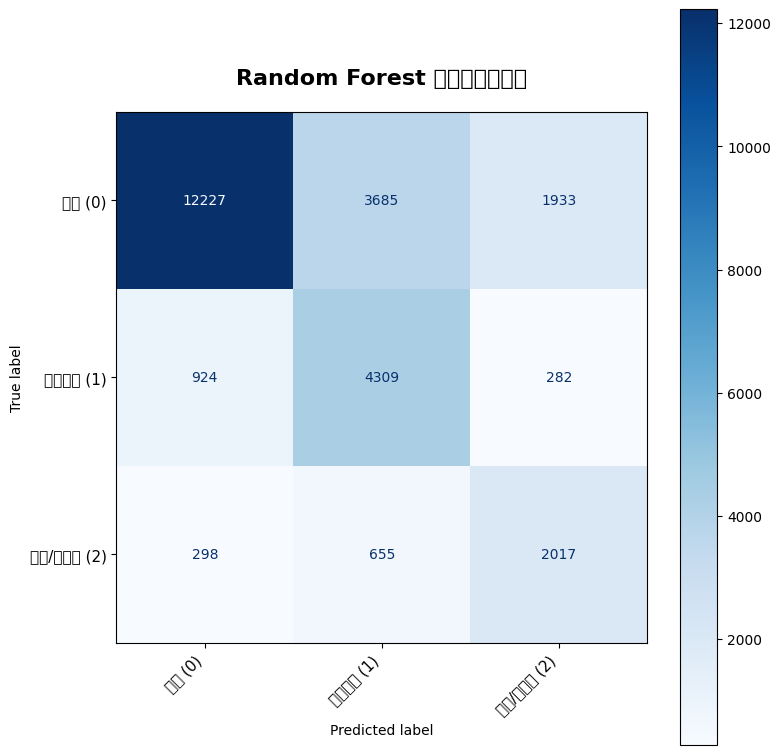

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("🌲 正在使用最佳參數訓練「終極 Random Forest 三分類」模型...")

# ==========================================
# 1. 建立並訓練最終模型 (這次只要跑一個模型，幾秒鐘就搞定！)
# ==========================================
best_rf_multi_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=2,
    class_weight='balanced', # 完美處理三分類的不平衡
    random_state=42,
    n_jobs=-1  # 既然是單一模型，就可以把所有 CPU 核心叫回來全力衝刺！
)

best_rf_multi_model.fit(X_train_multi, y_train_multi)
print("✅ 模型訓練完成！\n")

# ==========================================
# 2. 對期末考卷 (測試集) 進行預測
# ==========================================
print("📊 正在計算測試集成績單與 3x3 混淆矩陣...")
y_test_pred_multi = best_rf_multi_model.predict(X_test_multi)
y_test_proba_multi = best_rf_multi_model.predict_proba(X_test_multi)

# 計算三分類的 ROC-AUC (必須指定 multi_class='ovr')
auc_multi = roc_auc_score(y_test_multi, y_test_proba_multi, multi_class='ovr')

# ==========================================
# 3. 印出超專業期末成績單
# ==========================================
print("========================================")
print("🏆 Random Forest 三分類最終成績單")
print("========================================")
print(f"測試集 ROC-AUC (OVR): {auc_multi:.4f}\n")

print("[詳細分類報告 Classification Report]")
# 🚨 這裡我先假設你的 0, 1, 2 分別是出局、一壘安打、長打
# 如果你的定義不同，請自行修改這裡的文字！
target_names_multi = ['出局 (0)', '一壘安打 (1)', '長打/全壘打 (2)']
print(classification_report(y_test_multi, y_test_pred_multi, target_names=target_names_multi))

# ==========================================
# 4. 繪製 3x3 九宮格混淆矩陣
# ==========================================
cm_multi = confusion_matrix(y_test_multi, y_test_pred_multi)
disp_multi = ConfusionMatrixDisplay(
    confusion_matrix=cm_multi,
    display_labels=target_names_multi
)

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False
# 三分類的圖表需要大一點，比例才好看
fig, ax = plt.subplots(figsize=(8, 8))

# 使用藍色漸層
disp_multi.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Random Forest 三分類混淆矩陣', fontsize=16, fontweight='bold', pad=20)
plt.grid(False)

# 稍微旋轉底部的標籤，避免文字重疊
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()